# NIBLEs Tutorial Part 2: NMR Simulations

Now that we have a sample to work with, we will introduce the NIBLEs simulator using some basic NMR measurements.

To give you the big picture of coding a simulation with NIBLEs, a NIBLEs script should be broken down into 5 key sections:
* A block of inputs, where we import required libraries and define simulations parameters such as file paths, echo time, and the chosen relaxation model.
* A block of calculation code, where inputs are used to calculate required values before we begin proper simulation. Examples for these calculations include: precise timings of each sequence element, gradient amplitudes, RF phase cycling schemes etc.
* Creating an instance of the `Experiment` class, and changing any default parameters within `Experiment` as needed
* Calling the `sequence_start` function within our `Experiment` instance to load required sample information
* A block of code that uses the sequence element methods within `Experiment` to evolve magnetization, saving the results of any acquistion to file as the sequence pregresses

Let's start by running a simple free induction decay experiment. To begin, we must import the NIBLEs `Experiment` class. We will also need access to the functions in `NIBLEs.fieldfunc` and `NIBLEs.relaxfunc`. We will be making use of `matplotlib.pyplot`, and `NumPy` for various minor calculations and visiualizations, so let's import those as well.

In [ ]:
# Input your import statements
import numpy as np
import matplotlib.pyplot as plt

import NIBLEs.experiment as NIBLEs
import NIBLEs.fieldfunc as field
import NIBLEs.relaxfunc as relax

We now need to specify what sample we want to run a simulation on, and the details of how we want the solver to model relaxation. Please set the sample name to the sample you generated in Part 1 of this tutorial, and identify the path to the folder containing that sample.

When we created our sample in Part 1, we only defined constant $T_1$/$T_2$ values. In order to perform a simulation with constant relaxation times, we must give the solver the function `relax.constant`. This function simply takes the given $T_1$/$T_2$ values and returns those values regardless of other inputs. Please see the NIBLEs documentation for more details on relaxation functions.

NIBLEs uses a variable called `model_type` to specify how relaxation is to be modeled. It has a number of potential options, which are explained in detail in the NIBLEs documentation. For the purpose of this tutorial, please set `model_type` = `"Constant"`, which will load `Material.t1/t2` into memory as the main relaxation values to be used in simulation.

In [ ]:
# Define sequence name, path, and desired relaxation behaviour
sample_name = 'NIBLEsTutorial_NMR_1024Vectors_1x1_1.0cm'
sample_path = '/NIBLEs/samples'
relax_func = relax.constant
model_type = 'Constant'

Finally, for our experiment we need to specify the timings for our sequence. As we are perfroming a simple FID, we simply have to specify the parameters for our excitation pulse, and the acquisition window that follows it. For the RF pulse we need to specify 3 parameters:
* `duration` - Duration of pulse (s)
* `flip_angle` - Desired flip angle of pulse (degrees)
* `brf_func` - A function to calculate the pulse waveform

`NIBLEs.fieldfunc` contains a number of functions for defining RF pulse waveforms, for this tutorial let's stick with a simple sinc function, defined by `field.rf_sinc`. The duration of the RF pulse we leave up to you! However, we recommend a realistic pulse length from between 0.5 to 2 ms. For this tutorial, please set the excitation flip angle to 90 degrees.

For the acquisition window, we must define the duration of the acquisition window and the number of data points we wish to acquire during the acquisition. Please specify a duration of at least 50 ms, and a minimum of 100 data points so we can visualize our FID.

**Note:**  All units given to NIBLEs should be in SI units (meters, seconds, tesla, etc.). Angles should be specified in degrees. Furthermore, whenever we are defining a vector quantity in NIBLEs, that vector is input and saved in component form [x, y, z] in the lab reference frame. 



In [3]:
# Define RF pulse parameters
flip_angle = 90
rf_duration = 0.5e-3
brf_func = field.rf_sinc

# Define acquisition parameters
acq_dur = 50e-3
n_points = 100

In keeping with the NIBLEs script format outlined at the beginning of this notebook, at this point we should use our desired inpute to calculate the specific timing and field amplitude parameters needed for our sequence. However, as we are performing a simple FID we have no parameters that require calculating. Thus, we will move on to invoking the `Experiment` class.

The `Experiment` class is the primary tool for performing simulations with NIBLEs. It automatically manages the data inputs and outputs of the NIBLEs solver throughout a simulation. Individual sequence elements (gradients, RF pulses, etc.) are simulated using functions contained within `Experiment`.

To begin, we must create an instance of `Experiment`. When creating an `Experiment` instance, we must provide NIBLEs with the main field strength of our MR system (`B0`). NIBLEs expects B0 to be specified by a 3 element list detailing the x-, y-, and z-components of B0. For this example, we will use a B0 strength of 3T. Please set B0 = [0, 0, 3], and use the name `exp` for this instance of the Experiment class.


Additionally, as we are performing an NMR experiment with a high number of vectors per voxel, we need to adjust one of the parameters used by NIBLEs to replicate $T_2^*$ decay. immediately after creating and `Experiment` instance, please set `exp.t2_star_bounds` = `[0.001, 0.999]`. To avoid derailing the tutorial, the reasoning for this is laid out in an explanation section at the end of this tutorial.

In [4]:
# Create an Experiment instance, and change the default setting 
# 't2StarBounds'
exp = NIBLEs.Experiment(b0 = [0, 0, 3]) 
exp.t2_star_bounds = [0.001, 0.999]

Once we have an `Experiment` instance, our next task will be to load our sample from file into `Experiment`. This is done using the `sequence_start` function.

`sequence_start` requires its own inputs:
* `sample_name` - A string giving the name of the sample to be used
* `sample_path` - The path to the NIBLEs sample folder
* `relax_func` - The funtion to be used for calculating relaxation times during simulation
* `model_type` - A string indicating which set $T_1$/$T_2$ variables should be used

Conveniently, we have already defined these parameters above, please use them when calling `sequence_start`.

Note that by default, `sequence_start` will use the  constant relaxation model and will set `relax_func` and `model_type` to the parameters we have explicitly specified in this tutorial. 

In [5]:
# Import sample settings from file using sequence_start
exp.sequence_start(sample_name = sample_name, sample_path = sample_path,
                   relax_func = relax_func, model_type = model_type)

Loading Sample...


With our sample loaded, are now ready to begin calling sequence elements! 

To simulate the RF pulse, we need to call the `Experiment` function `rf_pulse`. This function will take our inputs, calibrate the field amplitude to produce the desired flip angle, and then evolve sample magnetization using the specified RF pulse. As rf_pulse runs, it will print status updates showing the calibration process, and when it applies the final RF pulse. This calibration process will take a noticable amount of time depending on your CPU, and will be performed by the first RF pulse called in each sequence unless a b1 amplitude is explicitly specified by the user.

To help you visualize what is happening, for this tutorial we will use the utility function `Experiment.net_mag_calc` to calculate the total net magnetization of the sample before and after the RF pulse is applied. Initally, net mangetization will be [0, 0, 1], indicating that all magnetization is at equilibrium along the z-axis. After the RF pulse (assumiong you provided a 90 degree excitation as iinstructed), net magnetization will lie prodominantly in the y-axis, with small factors in the x- and z-axes. The variable `Experiment.M` that we analyse in this demonstration is the internal variable that stores the current state of magnetization for the sample.

**Additional Note**: because `Experiment` sequence element functions evolve the current state of magnetization, if you re-run a cell in this notebook you will be evolving magnetization from where it was at the end of the call of `rf_pulse`. If you make a mistake or want to rerun a sequence element under different parameters, please restart the notebook and run again from the beginning!

In [6]:
# Don't touch this code
exp.net_mag_calc(exp.sample_mag)
print(f"Initial net magnetization is {exp.net_mag}")

# Apply an RF pulse to your sample
exp.rf_pulse(duration = rf_duration, brf_func = brf_func,
             flip_angle = flip_angle)

# Don't touch this code
exp.net_mag_calc(exp.sample_mag)
print(f"Net magnetization after the RF Pulse is {exp.net_mag}")

Initial net magnetization is [0. 0. 1.]
Calculating b90 Amplitude...
Transverse Mag = 0.2299340990133822 @ b90 = 1e-05 T
Transverse Mag = 0.44689279796599085 @ b90 = 2e-05 T
Transverse Mag = 0.6386319508385144 @ b90 = 3.0000000000000004e-05 T
Transverse Mag = 0.7943286758293755 @ b90 = 4e-05 T
Transverse Mag = 0.9051912105312915 @ b90 = 5e-05 T
Transverse Mag = 0.9649542282316932 @ b90 = 6e-05 T
Transverse Mag = 0.9702317092929138 @ b90 = 7.000000000000001e-05 T
Transverse Mag = 0.9207074952325601 @ b90 = 8e-05 T
Reducing Step Size....
Transverse Mag = 0.9679634392810899 @ b90 = 6.1000000000000005e-05 T
Transverse Mag = 0.9704235208826656 @ b90 = 6.2e-05 T
Transverse Mag = 0.9723330616469545 @ b90 = 6.3e-05 T
Transverse Mag = 0.9736909618045378 @ b90 = 6.4e-05 T
Transverse Mag = 0.9744964340956885 @ b90 = 6.5e-05 T
Transverse Mag = 0.9747490032590427 @ b90 = 6.599999999999999e-05 T
Transverse Mag = 0.9744485076671611 @ b90 = 6.699999999999999e-05 T
Reducing Step Size....
Transverse Mag

Now that we have excited magnetization, we want to run an acquisition window to measure sample magnetization as it relaxes. To do this, we must use the `Experiment.acquisition` function. This function requires inputs specifying the duration of the acquisition window and the number of data points we wish to acquire. 

By default, NIBLEs acquisitions acquire signal in quadriture, and store that data as a complex number. All acquisition functions used by `Experiment` will save the resulting complex-valued data in the variable `Experiment.readout`. This output is measured in the reference frame rotating at the Larmor frequency. For this tutorial, we have provided some simple plotting code to allow you to visualize the acquired signal.

In [7]:
# Run an acquisition

exp.acquisition(duration = acq_dur, n_points = n_points)

acquisition: n_points = 100


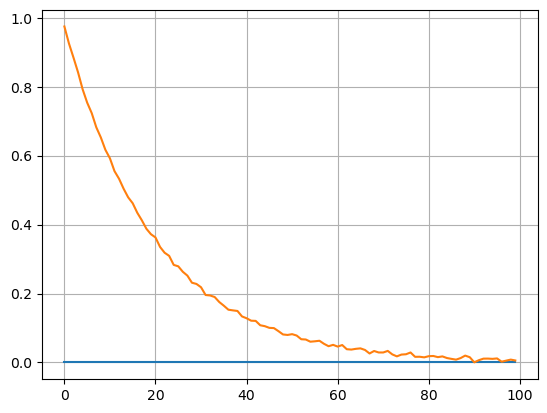

In [8]:
# Don't touch this cell
plt.plot(np.real(exp.readout))
plt.plot(np.imag(exp.readout))
plt.grid()
plt.show()

With our chosen parameters, you should see zero signal along the real channel of measured signal (corresponding to the x-axis), and a nice exponential decay from 1 to zero in the imaginary channel (y-axis). While we will not explicitly fit this decay (to not lose focus in this tutorial), if you followed instructions in Part 1, you will see that our FID returns approximately to zero by 100 ms, which is $5 T_2^*$ and is what we'd expect to see.

To wrap up this experiment, let's evolve mangetization back to equilibrium. For this, we will use the `Experiment.deadtime` function, which evolves magnetization for a period of time under the sole influence of B0. As no other fields are being applied to the sample, we only need to specify the duration of this deadtime. Please specify a duration of at least 5 seconds (or $5 T_1$), and the resulting call to netMagCalc should show that net sample magnetization has returned to equilibrium along the z-axis!

In [9]:
# Set deadtime duration and evolve magnetization
dead_dur = 5
exp.deadtime(duration = dead_dur)

# Don't touch this code
exp.net_mag_calc(exp.sample_mag)
print(f"Net magnetization after given time to relax is {exp.net_mag}")

Evolving over Deadtime: Dur = 5 s
Net magnetization after given time to relax is [2.05207447e-19 3.49687373e-11 9.93625786e-01]


Congradulations on performing your first simulation with NIBLEs! 


To expand your knowledge and practice using NIBLEs, let us now simulate a CPMG sequence. Before we can begin, however, we need to expand on a couple points.

Firstly, `rf_pulse` uses more than the 3 parameters specified above to define an RF pulse. These additional parameters are:

* `phi` - Axis in the transverse plane along which the RF field is applied. Specified in degrees, where `0` denotes the +x-axis, and `90` denotes the +y-axis. By default, `phi = 0`
* `del_omega` - Frequency difference between the carrier frequency of the RF pulse and the Larmor frequency. By default, `del_omega = 0`
* `n_lobes` - A parameter for defining the shape of the RF pulse. In out Sinc function this specifies the number of lobes in the pulse to be applied. By default, `n_lobes = 5`
* `b1` - RF pulse amplitude. If this parameter is `0`, `rf_pulse` will calculate the amplitude needed to achieve the specified flip angle (see documentation for more details). If this parameter is non-zero `rf_pulse` will simply use the value you give it. By default, `b1 = 0`
* `**kwargs` - rf_pulse (and all other sequence elements that invoke an RF field or a magnetic gradient) allow the user to specify any number of additional keyword arguments. These allow for more complex magnetic fields to be defined. For futher details, please refer to the NIBLEs documentation.

As you can see from these parameter defaults, the excitaiton pulse we applied above was a 5-lobe Sinc pulse, applied along the +x-axis at the Larmor frequency. For our CPMG experiment, we can leave most of these parameters at their default values, however as a CPMG requires phase cycling of the RF pulse we will have to specify different `phi` values throughout the sequence.


Secondly, the output of an acquisiton (`Experiment.readout`) is overwritten by each new acquisition. As we will be acquiring multiple echoes in the CPMG experiment, we need to arrange and store our acquired data in another variable. The `Experiment.signal` variable is designed for this purpose, and is used by the various data post-processing functions built into NIBLEs. In order to accomodate different ways of arranging the acquired signal, `Experiment.signal` must be defined manually, prior to data acquisition. Whenever possible, please make `Experiment.signal` a Numpy array.


As we have already imported the relevant libraries, sample path, and relaxation behaviours, we will not do so again for our CPMG experiment. However, we do need to specify some additional timing parameters. For a CPMG sequence, we need to define the duration of our RF pulses and 2 echo times: the time between our excitation pulse and the first 180 degree pulse (`te1`), and the time between 180 degree pulses (`te2`). We further must specify the number of echoes in our CPMG echo train, and the duration/number of points of our acquisition. Feel free to choose these as you see fit, if you're feeling uncreative use 8 echoes and 100 points per acquisition. Please set `te2` equal to double `te1`, and ensure that your chosen acquisition time is shorter than `te2`.


In [10]:
# Define sequence timings and parameters
rf_dur = 1.28e-3
te1 = 15e-3
te2 = 30e-3
n_echo = 8
n_points = 100
acq_dur = te2/2

We now must calculate some timing parameters. We assume the reader is familiar with some pulse sequence programming, but as a refresher: while magnetization is rotated by an RF pulse over the entire duration of the pulse, when calculating the timings of a pulse sequence we pretend that the full rotation happens instantaneouly at the temporal midpoint for the RF pulse. Thus, our echo times here define the time between the midpoints of the relevant RF pulses. In order to produce echoes at the intended timings, the time between RF pulses must therefore account for the length of the RF pulse itself. 

Furthermore, when we introduce an acquisition window between two RF pulses, we need to know the dead time between the first RF pulse and the beginning of the acqusition, and the dead time following the acquisition and the next RF pulse. If we decide to center the acquisition window between our pulses, these two timings will be the same. 

Thus, for our CPMG experiment we need to calculate at least two timing parameters here: the time between the excitation pulse and the first 180 pulse of the CPMG train; and the time between the first 180 pulse and the acquisition window. As the nature of these calculations is not specific to the NIBLEs simulator, we have provided the calculations below assuming that the desired acquisition window is centered within the delay between 180 pulses.

In [11]:
# Calculate Timing Parameters
te1_deadtime = te1 - rf_dur
te2_deadtime = (te2- acq_dur- rf_dur)/2

 We can now create a new instance of `Experiment` named `exp2` in the cell below, and load our NMR sample into this new `Experiment` instance. Please uses the same parameters we specified for the FID example above. Also, don't forget to set `Experiment.t2_star_bounds` before calling `sequence_start`!

In [12]:

exp2 = NIBLEs.Experiment(b0 = [0, 0, 3])
exp2.t2_star_bounds = [0.001, 0.999]
exp2.sequence_start(sample_name = sample_name, sample_path = sample_path,
                    relax_func = relax_func, model_type = model_type)

Loading Sample...


Before we being the sequence proper, let's set up `Experiment.signal`. For this tutorial, we will save our signal in a 2D array where each row is a new acquisition. Note that the size of `Experiment.signal` will thus depend on the number of echoes we acquire and the number of data points we acquire in each acquisiton window. Please construct a Numpy array of zeros with dimensions defined by these variables. 

Note that in order to store the complex signal produced by NIBLEs, we need to specify that `Experiment.signal` is an array of complex numbers at this point. Please do this with an `.astype()` statement.

In [13]:
# Define exp2.signal as an empty array, using your planned numer of 
# echoes and number of acquisition points
exp2.signal = np.zeros([n_echo, n_points]).astype(complex)

Finally, let's code the sequence itself. Using the functions we called in the FID experiment, code a CPMG experiment. To save us from adjusting this code when acquiring a different number of echoes, please use a `for` loop to acquire an arbitrary number of echoes, and an `if` statement to determine the phase of the 180 degree pulses. For this tutorial, please apply the excitation pulse along the +y-axis, and the 180 pulses along the +/- x-axes (use the description of `phi` above). Don't forget to save your acquired data in `Experiment.signal` with each acquisition!

In the cell below, we've included some plotting code to help visualize your simulation outputs. If you have followed the instructions provided, you should see a series of sequentially decreasing spin echoes!

In [ ]:
# Apply Excitation Pulse
exp2.rf_pulse(duration = rf_dur, brf_func = field.rf_sinc, flip_angle = 90,
              phi = 90)
exp2.deadtime(duration = te1_deadtime)

# Apply Echo Train and save resultant signal
for i in range(n_echo):

    if i % 2 == 0:
        exp2.rf_pulse(duration = rf_dur, brf_func = field.rf_sinc,
                      flip_angle = 180, phi = 0)
    else:
        exp2.rf_pulse(duration = rf_dur, brf_func = field.rf_sinc,
                      flip_angle = 180, phi = 180)

    exp2.deadtime(te2_deadtime)
    exp2.acquisition(duration = acq_dur, n_points = n_points)
    exp2.signal[i, :] = exp2.readout
    exp2.deadtime(te2_deadtime)



Calculating b90 Amplitude...
Transverse Mag = 0.5362849923225604 @ b90 = 1e-05 T
Transverse Mag = 0.8786830737126923 @ b90 = 2e-05 T
Transverse Mag = 0.9031046372074759 @ b90 = 3.0000000000000004e-05 T
Transverse Mag = 0.5999329653931328 @ b90 = 4e-05 T
Reducing Step Size....
Transverse Mag = 0.8965735232409838 @ b90 = 2.1000000000000002e-05 T
Transverse Mag = 0.9111176994659208 @ b90 = 2.2000000000000003e-05 T
Transverse Mag = 0.9222607548674967 @ b90 = 2.3000000000000003e-05 T
Transverse Mag = 0.9299604691149527 @ b90 = 2.4000000000000004e-05 T
Transverse Mag = 0.9341874040149137 @ b90 = 2.5000000000000005e-05 T
Transverse Mag = 0.9349250142924681 @ b90 = 2.6000000000000005e-05 T
Transverse Mag = 0.9321697082646114 @ b90 = 2.7000000000000006e-05 T
Reducing Step Size....
Transverse Mag = 0.9344183455492445 @ b90 = 2.5100000000000004e-05 T
Transverse Mag = 0.9346143738002309 @ b90 = 2.5200000000000003e-05 T
Transverse Mag = 0.9347754805656278 @ b90 = 2.5300000000000002e-05 T
Transverse

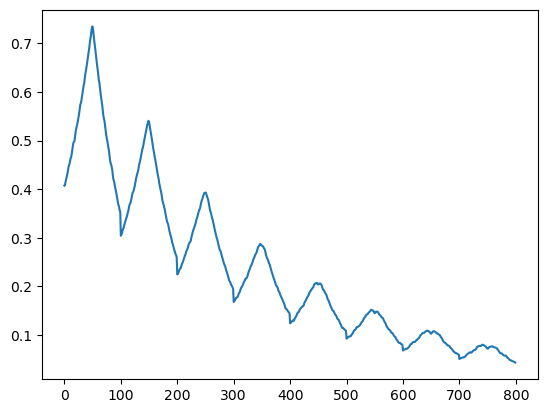

In [15]:
plt.plot(np.abs(exp2.signal.reshape(-1)))

Finally, now that we have some data it would be useful to save that data to file so it can be re-analyzed later. For this, we can make use of the `save_acquisition` function. This function will save the given array as a `.csv` file, named after: the sample; the time at which you started the simulation; and pulse sequence you have used. Additionally, `save_acquisition` will construct a `.txt` file listing every sequence element used in the current experiment and the parameters with which they were run.

When calling `save_acquisition`, you must specify:
* `variable` - Numpy array to be saved
* `seq_name` - Name of the sequence being run, as a string
* `sample_name` - Name of the sample being used, as a string

In this example, we already know our sample file name, so you simply need to specify that this data is from a CPMG sequence.

**Note:** For the purposes of this tutorial, we are saving our results after the full sequence has been run. As a best practice, we recommend calling `save_acquisition` immediately after each acquisition in your simulation. This ensures that if your simulation is interrupted, any simulated results are already saved to file.

In [ ]:
seq_name = 'CPMG'

exp2.save_acquisition(variable = exp2.signal, seq_name = seq_name,
                      sample_name = sample_name)

Typically, NIBLEs simulations should be run as scripts (i.e. not in a jupyter notebook). We have provided the CPMG experiment defined here in script form as `Tutorial_CPMG.py` in the `/NIBLEs-Source/tutorial/tutorial_completed` folder.

#### Congratulations, you have completed Part 2 of this tutorial. Please continue to Part 3, where we will create some more complex samples in preparation for MR imaging simulations!


### Explanation of Vector Number and `Experiment.t2_star_bounds` Values

In this tutorial series, our chioices for the number of vectors per voxel and the `Experiment.t2_star_bounds` parameter are determined by the model used by NIBLEs to reproduce $T_2^*$ relaxation. NIBLEs reproduces $T_2^*$ by assigning a number of vectors to each voxel, then assigning each vector a small field offset calculated using the expression:

$ \Delta B = \frac{1}{\gamma T_2'} tan( \pi (\chi -0.5))$

Where $\gamma$ is the gyromagnetic ratio of your nucleus, $T_2'$ is the reversible component of $T_2^*$ decay, and $\chi$ is a variable parameter that ranges from [0, 1]. Each vector is assigned a unique $\chi$ value, resulting in a unique field offset. These field offsets cause the vectors within a voxel to precess at slightly different rates, resulting in reversible exponential $T_2$ decay. This calculation is performed by `Experiment.sequence_start` at the begnining of a simulation.

However, this function diverges to infinite values that Python cannot handle at 0 and 1. To avoid these infinites, we have to generate these field offsets across a smaller range of $\chi$ values, defined in NIBLEs using the variable `Experiment.t2_star_bounds`. While this prevents infinities from appearing in our calculations, this degrades the quality of our $T_2^*$ reproduction as the limited sampling of this function produces sinusoidal variability on top of the intended exponential decay. From our work developing NIBLEs, we determined that for NMR experiments it is best to use a large number of vectors ( >1000 vec/vox) and a wide $\chi$ range [0.001, 0.999] to minimize this sinusoidal component and ensure precise $T_2^*$ reproduction. For an imaging experiment, to minimize simulation time while still maintining acceptably accurate $T_2^*$ reproduction, we found it is best to use 12 vec/vox with a $\chi$ range of [0.075, 0.925]. NIBLEs by default assumes that you are performing an imaging experiment, and sets `Experiment.t2_star_bounds` equal to the latter range for $\chi$ when an instance of `Experiment` is created. If you are performing an NMR experiment, you will have to manually set `Experiment.t2_star_bounds` to the wider $\chi$ range before calling `Experiment.sequence_start`, as we have done in this section of the tutorial.

For additional exploration of this topic, please see our paper {CITATION}

